The goal is to wrangle our dataset to meet the criteria for antibiogram generation. 

<u>Antibiogram Data Inclusion/Exclusion Guidelines per CLSI M39</u>

- Only diagnostic isolates, not surveillance isolates
- Only final, verified results
- Duplicate data eliminated by including only the first isolate of a species per patient per year, regardless of specimen source or susceptibility profile
- Only species with testing data for >= 30 isolates

The original data is the MIMIC dataset, with the first subset pulled to include only records with an organism present that had interpretable susceptibility testing performed and released. This was done via SQL:
```sql
SELECT * 
FROM mimiciv_hosp.microbiologyevents 
WHERE org_name IS NOT NULL 
AND ab_name IS NOT NULL 
AND interpretation IS NOT NULL
```

Python libraries will be used to further tailor the data to meet the above restrictions.

**Disclaimer:** The date and time data from MIMIC has been de-identified and scrambled, so all datetime data was discarded. Though this is a criteria in the deduplication to only have one isolate per patient per year, this point was not able to be met due to the nature of the data.

In [3]:
# tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()


In [4]:
# making CSV generated from SQL query above into a pandas DataFrame
micro_events = pd.read_csv('micro_events.csv', low_memory=False)

<h1 style="text-align: center;">Initial Data Exploration:</h1>

In [5]:
# getting a sense of the data
micro_events.head(5)

,microevent_id,subject_id,hadm_id,micro_specimen_id,order_provider_id,chartdate,charttime,spec_itemid,spec_type_desc,test_seq,...,org_name,isolate_num,quantity,ab_itemid,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,comments
0,20,10000032,NaN,159861,NaN,2180-06-26 00:00:00,2180-06-26 18:30:00,70079,URINE,1,...,ENTEROCOCCUS SP.,1,NaN,90004,AMPICILLIN,<=2,<=,2.0,S,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO..."
1,21,10000032,NaN,159861,NaN,2180-06-26 00:00:00,2180-06-26 18:30:00,70079,URINE,1,...,ENTEROCOCCUS SP.,1,NaN,90010,NITROFURANTOIN,<=16,<=,16.0,S,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO..."
2,22,10000032,NaN,159861,NaN,2180-06-26 00:00:00,2180-06-26 18:30:00,70079,URINE,1,...,ENTEROCOCCUS SP.,1,NaN,90011,TETRACYCLINE,=>16,=>,16.0,R,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO..."
3,23,10000032,NaN,159861,NaN,2180-06-26 00:00:00,2180-06-26 18:30:00,70079,URINE,1,...,ENTEROCOCCUS SP.,1,NaN,90015,VANCOMYCIN,1,=,1.0,S,"MIXED BACTERIAL FLORA ( >= 3 COLONY TYPES), CO..."
4,75,10000280,NaN,5501763,P472Z0,2150-10-12 00:00:00,2150-10-12 11:35:00,70070,SWAB,2,...,STAPH AUREUS COAG +,1,NaN,90003,PENICILLIN G,=>0.5,=>,0.5,R,NaN


In [6]:
micro_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1410258 entries, 0 to 1410257
Data columns (total 25 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   microevent_id        1410258 non-null  int64  
 1   subject_id           1410258 non-null  int64  
 2   hadm_id              532706 non-null   float64
 3   micro_specimen_id    1410258 non-null  int64  
 4   order_provider_id    420647 non-null   object 
 5   chartdate            1410258 non-null  object 
 6   charttime            1284708 non-null  object 
 7   spec_itemid          1410258 non-null  int64  
 8   spec_type_desc       1410258 non-null  object 
 9   test_seq             1410258 non-null  int64  
 10  storedate            1410231 non-null  object 
 11  storetime            1410231 non-null  object 
 12  test_itemid          1410258 non-null  int64  
 13  test_name            1410258 non-null  object 
 14  org_itemid           1410258 non-null  int64  
 15

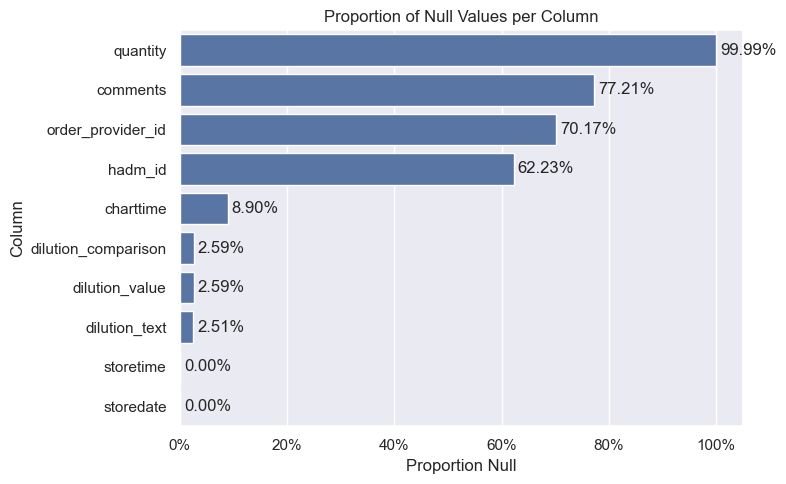

In [7]:
# exploratory analysis - bar plot of null values
# taking the mean of null values gives us the proportion of nulls in each column
null_proportions = micro_events.isnull().mean()
# filter to only columns with null values and sort in descending order
null_proportions = null_proportions[null_proportions > 0].sort_values(ascending=False)

# create a horizontal bar plot of the null proportions
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(y=null_proportions.index, x=null_proportions.values, ax=ax)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2%}', 
                xy=(p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(3, 0),
                textcoords='offset points',
                va='center')

ax.set_title('Proportion of Null Values per Column')
ax.set_xlabel('Proportion Null')
ax.set_ylabel('Column')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

In [ ]:
# investigating the content of the columns with high null proportions
# read through comments, okay to drop
display(micro_events['quantity'].value_counts())
display(micro_events['comments'].value_counts())


quantity
>100,000 CFU/mL          44
10,000-100,000 CFU/mL    42
SPARSE GROWTH            32
MODERATE                 16
1 COLONY                  7
RARE                      7
1                         4
Name: count, dtype: int64

comments
___                                                                                                                                                                                                                                                                                                                                                                                                                      90931
Culture workup discontinued. Further incubation showed contamination with mixed skin/genital flora. Clinical significance of isolate(s) uncertain. Interpret with caution.                                                                                                                                                                                                                                               62657
Commensal Respiratory Flora Absent.                                                                                                                              

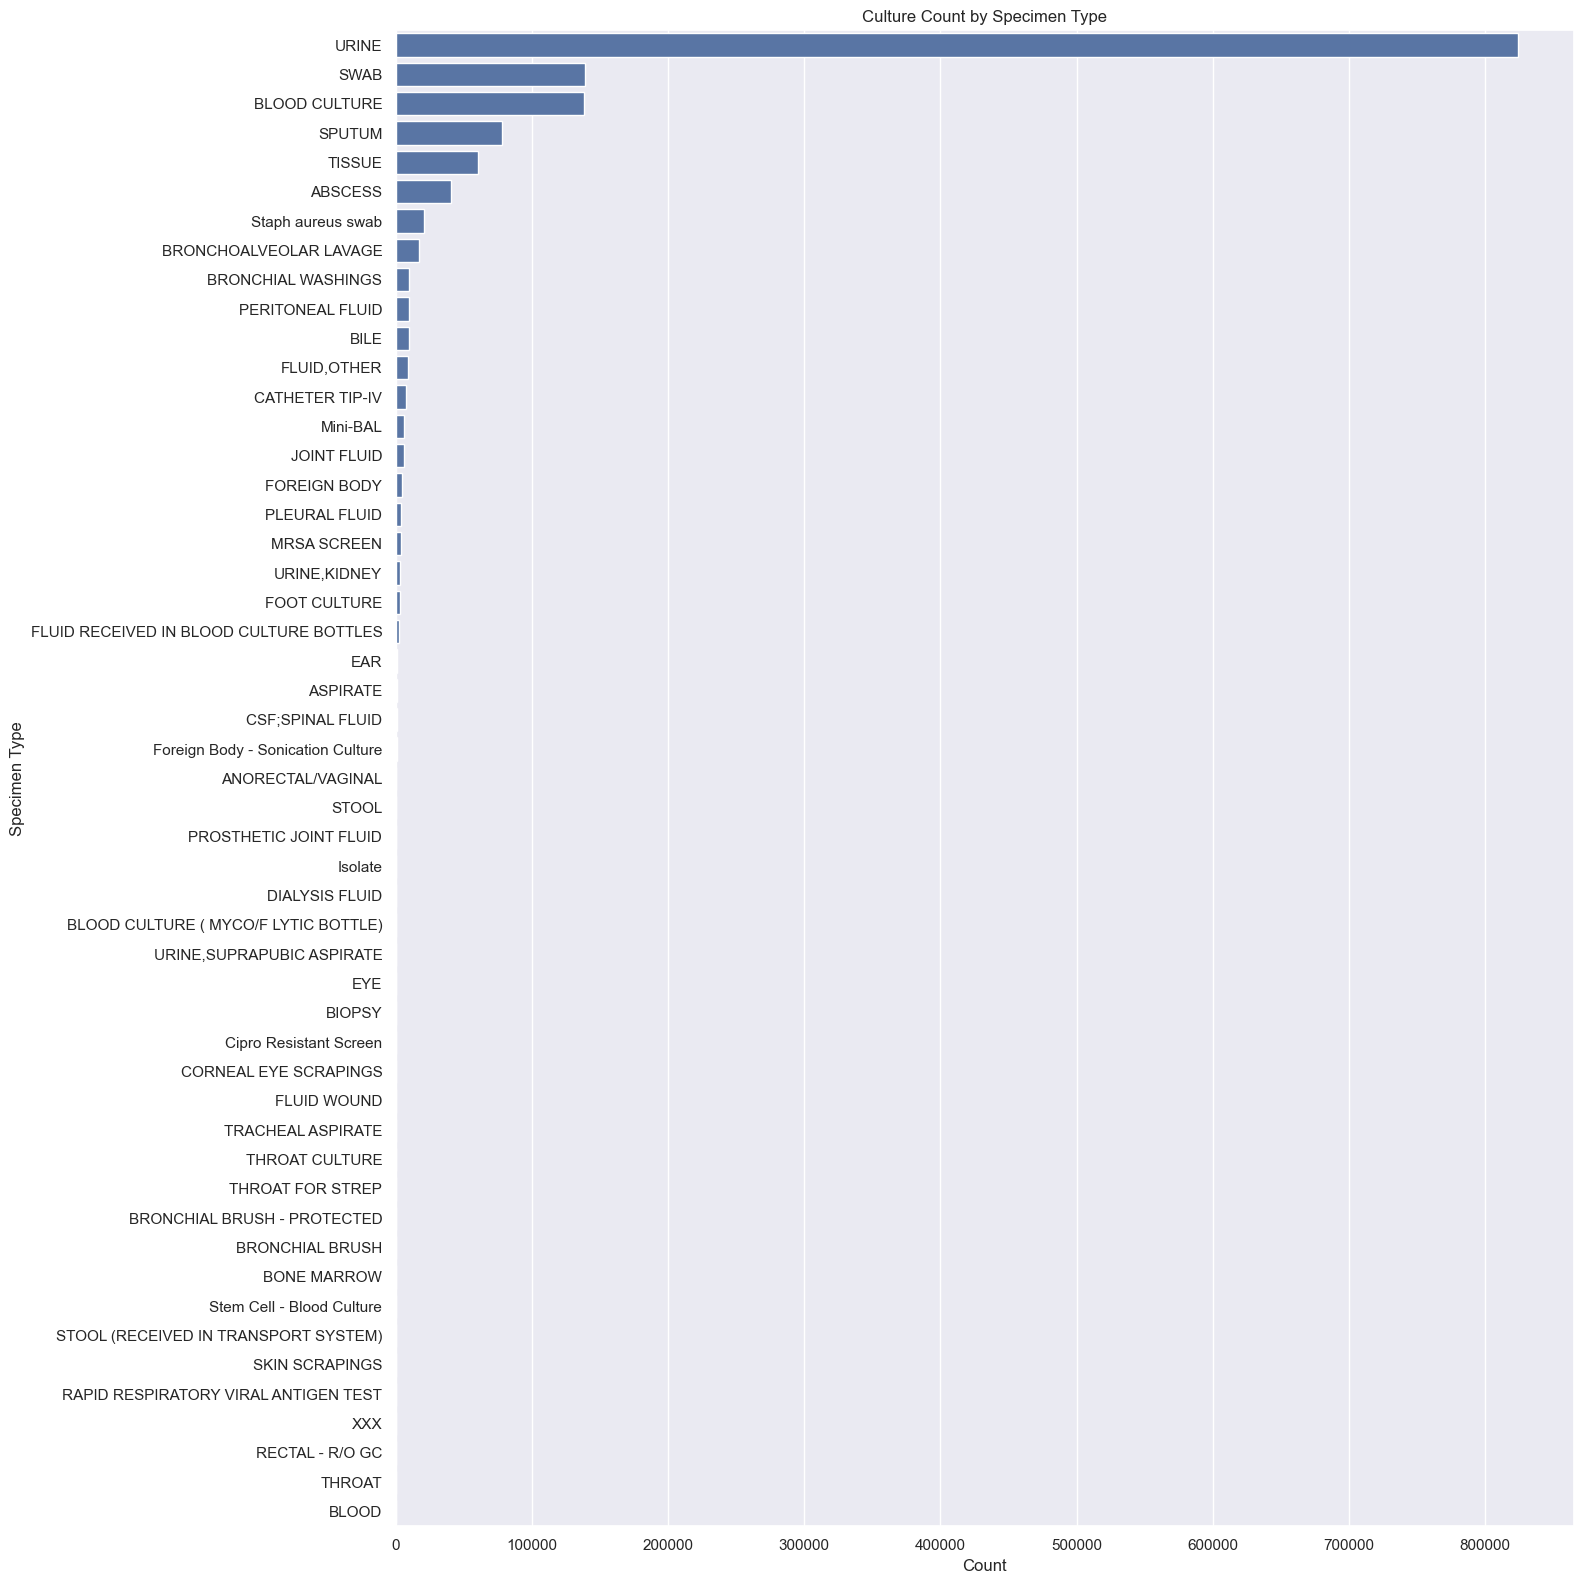

In [9]:
# checking out specimen sources
fig, ax = plt.subplots(figsize=(16, 16))

sns.countplot(y=micro_events['spec_type_desc'], 
              order=micro_events['spec_type_desc'].value_counts().index,
              ax=ax)

ax.set_title('Culture Count by Specimen Type')
ax.set_xlabel('Count')
ax.set_ylabel('Specimen Type')

plt.tight_layout()
plt.show()

In [10]:
# continuing specimen source investigation
display(micro_events['spec_type_desc'].value_counts())
micro_events['spec_type_desc'].nunique()

spec_type_desc
URINE                                      823897
SWAB                                       139207
BLOOD CULTURE                              138650
SPUTUM                                      78225
TISSUE                                      60451
ABSCESS                                     40839
Staph aureus swab                           20865
BRONCHOALVEOLAR LAVAGE                      16911
BRONCHIAL WASHINGS                          10208
PERITONEAL FLUID                            10181
BILE                                         9639
FLUID,OTHER                                  9060
CATHETER TIP-IV                              7848
Mini-BAL                                     6553
JOINT FLUID                                  6308
FOREIGN BODY                                 4930
PLEURAL FLUID                                4305
MRSA SCREEN                                  3962
URINE,KIDNEY                                 3073
FOOT CULTURE                       

51

Surveillance sources from above output: 

MRSA SCREEN,
Cipro Resistant Screen,
Staph aureus swab


In [11]:
# investigating certain columns for metadata purposes
print(micro_events['microevent_id'].nunique())

# testing if spec_itemid = spec_type_desc
# 70003 should point to abscess if so
specid = micro_events[micro_events['spec_itemid'] == 70003]
print(specid['spec_type_desc'].value_counts())
spec = micro_events[micro_events['spec_type_desc'] == 'ABSCESS']
print(spec['spec_type_desc'].value_counts())

# testing if test_itemid = test_name
# 90039 should point to urine culture if so
testid = micro_events[micro_events['test_itemid'] == 90039]
print(testid['test_name'].value_counts())
testname = micro_events[micro_events['test_name'] == 'URINE CULTURE']
print(testname['test_name'].value_counts())

# investigating column 'test_seq'
# multi_test = micro_events[micro_events['test_seq'] > 1]
# display(multi_test[['subject_id', 'micro_specimen_id', 'test_seq', 'test_name', 'org_name']].head(20))
# example patients with test_seq > 1
# 10000280, 10001186, 10001217, 10737771, 10763166
# investigating example patients
# micro_events[micro_events['subject_id'] == 10737771]

1410258
spec_type_desc
ABSCESS    40839
Name: count, dtype: int64
spec_type_desc
ABSCESS    40839
Name: count, dtype: int64
test_name
URINE CULTURE    793947
Name: count, dtype: int64
test_name
URINE CULTURE    793947
Name: count, dtype: int64


Metadata to help with context:

| Column Name | Description |
|-------------|-------------|
| microevent_id | random numeric, unique per record |
| subject_id | patient identifier numeric |
| hadm_id | hospital admission numeric (outpatient if NULL) |
| micro_specimen_id | each unique collection per patient (numeric) |
| order_provider_id | provider identifier numeric |
| chartdate | scrambled |
| charttime | scrambled |
| spec_itemid | specimen source identifier numeric |
| spec_type_desc | specimen source text |
| test_seq | enumerating test number on patients with multiple tests (?) |
| storedate | scrambled |
| storetime | scrambled |
| test_itemid | test order numeric |
| test_name | test order text |
| org_itemid | organism numeric |
| org_name | organism text |
| isolate_num | for patients with multiple orgs in one culture, orgs are counted 1, 2, 3, etc. |
| quantity | quantification of amount of organism growing in culture (mostly NULL) |
| ab_itemid | antibiotic numeric |
| ab_name | antibiotic text |
| dilution_text | MIC value sign plus numeric |
| dilution_comparison | MIC value comparison sign only |
| dilution_value | MIC value numeric only |
| interpretation | antibiotic efficacy (S/I/R) |
| comments | additional charted information |

<h1 style="text-align: center;">Data Cleaning:</h1>

In [ ]:
# Dropping unecessary columns
# if we wanted to delineate inpatient vs outpatient we could keep hadm_id -- keeping for now

col_to_drop = ['order_provider_id', 'chartdate', 'charttime', 'test_seq',
       'storedate', 'storetime', 'quantity', 'dilution_text', 'comments']
micro_events.drop(columns=col_to_drop, inplace=True)

In [13]:
# deduplicating data per CLSI M39 Guidelines (except for year)
# keeping first occurrence of each patient + organism combination
first_isolates = (micro_events
    .drop_duplicates(subset=['subject_id', 'org_name'], keep='first')
    [['subject_id', 'org_name', 'micro_specimen_id']]
)

# keep all antibiotic rows for those specimens
micro_events_dedup = micro_events.merge(first_isolates,
                                        on=['subject_id', 'org_name', 'micro_specimen_id'])

# checking the output 
print(f"Before: {len(micro_events)} rows")
print(f"After: {len(micro_events_dedup)} rows")
print(f"Removed: {len(micro_events) - len(micro_events_dedup)} rows")

Before: 1410258 rows
After: 881227 rows
Removed: 529031 rows


In [14]:
# confirming that the deduplication worked by grouping on subject and org
# if it worked, max of .nunique() should be 1
micro_events_dedup.groupby(['subject_id', 'org_name'])['micro_specimen_id'].nunique().max()


1

In [15]:
# finding surveillance/irrelevant cultures
micro_events_dedup['spec_type_desc'].value_counts()

spec_type_desc
URINE                                      517262
SWAB                                        89139
BLOOD CULTURE                               86017
SPUTUM                                      45572
TISSUE                                      35447
ABSCESS                                     26515
Staph aureus swab                           17787
BRONCHOALVEOLAR LAVAGE                       9657
PERITONEAL FLUID                             6340
BILE                                         6269
FLUID,OTHER                                  5770
BRONCHIAL WASHINGS                           4869
Mini-BAL                                     4014
JOINT FLUID                                  3461
CATHETER TIP-IV                              3390
MRSA SCREEN                                  3348
PLEURAL FLUID                                2803
FOREIGN BODY                                 2301
FLUID RECEIVED IN BLOOD CULTURE BOTTLES      1959
FOOT CULTURE                       

In [16]:
# finding surveillance/irrelevant cultures
micro_events_dedup['test_name'].value_counts()

test_name
URINE CULTURE                                                    496210
WOUND CULTURE                                                     98956
Blood Culture, Routine                                            84122
RESPIRATORY CULTURE                                               71741
FLUID CULTURE                                                     45382
TISSUE                                                            35531
REFLEX URINE CULTURE                                              21076
Staph aureus Screen                                               17974
MRSA SCREEN                                                        3108
Fluid Culture in Bottles                                           1941
AEROBIC BOTTLE                                                      989
R/O VANCOMYCIN RESISTANT ENTEROCOCCUS                               758
Sonication culture, prosthetic joint                                652
ISOLATE FOR MIC                                       

In [17]:
# excluding surveillance items and irrelevant/inappropriate test/specimen types, as well as yeast and GNRs

filter = (
    micro_events_dedup['test_name'].str.contains(
        'r/o|chlamydia|screen|mic|yeast', 
        case=False, na=False) |
    micro_events_dedup['spec_type_desc'].str.lower().isin([
        "mrsa screen",
        "cipro resistant screen", 
        "staph aureus swab", 
        "xxx", 
        "throat for strep", 
        "rapid respiratory viral antigen test"
        ]) |
    micro_events_dedup['org_name'].str.lower().isin([
        'candida albicans',
        'GRAM NEGATIVE ROD(S)'
    ])
)

filtered_micro_events = micro_events_dedup[~filter]
display(filtered_micro_events['spec_type_desc'].value_counts())
display(filtered_micro_events['test_name'].value_counts())

spec_type_desc
URINE                                      517254
SWAB                                        88225
BLOOD CULTURE                               85702
SPUTUM                                      45560
TISSUE                                      35429
ABSCESS                                     26511
BRONCHOALVEOLAR LAVAGE                       9656
PERITONEAL FLUID                             6338
BILE                                         6266
FLUID,OTHER                                  5765
BRONCHIAL WASHINGS                           4869
Mini-BAL                                     4013
JOINT FLUID                                  3461
CATHETER TIP-IV                              3390
PLEURAL FLUID                                2800
FOREIGN BODY                                 2299
FLUID RECEIVED IN BLOOD CULTURE BOTTLES      1958
FOOT CULTURE                                 1805
URINE,KIDNEY                                 1272
EAR                                

test_name
URINE CULTURE                           496208
WOUND CULTURE                            98945
Blood Culture, Routine                   84097
RESPIRATORY CULTURE                      71527
FLUID CULTURE                            45366
TISSUE                                   35523
REFLEX URINE CULTURE                     21075
Fluid Culture in Bottles                  1940
AEROBIC BOTTLE                             989
Sonication culture, prosthetic joint       651
ANAEROBIC BOTTLE                           637
FECAL CULTURE                              335
BLOOD/FUNGAL CULTURE                       154
ANAEROBIC CULTURE                          117
GENITAL CULTURE                             46
GENITAL CULTURE FOR TOXIC SHOCK             35
Stem Cell Aer/Ana Culture                   22
Name: count, dtype: int64

In [18]:
# Removing isolates that appear less than 30 times
# grouping on subject_id, as the org will appear multiple times for one patient for each antibiotic tested
species_counts = filtered_micro_events.groupby('org_name')['subject_id'].nunique()

valid_species = species_counts[species_counts >= 30].index

filtered_micro_events = filtered_micro_events[filtered_micro_events['org_name'].isin(valid_species)]

pd.set_option('display.max_rows', 100)
print(filtered_micro_events['org_name'].value_counts())

org_name
ESCHERICHIA COLI                                                          331172
STAPH AUREUS COAG +                                                       101149
KLEBSIELLA PNEUMONIAE                                                      97286
PROTEUS MIRABILIS                                                          47901
PSEUDOMONAS AERUGINOSA                                                     41334
ENTEROCOCCUS SP.                                                           35843
STAPHYLOCOCCUS, COAGULASE NEGATIVE                                         32104
ENTEROBACTER CLOACAE COMPLEX                                               18284
KLEBSIELLA OXYTOCA                                                         17296
SERRATIA MARCESCENS                                                        11303
CITROBACTER FREUNDII COMPLEX                                               10372
ENTEROBACTER AEROGENES                                                      9916
STAPHYLOCOCCUS EPID

In [19]:
filtered_micro_events['org_name'] = filtered_micro_events['org_name'].str.lower().str.strip()

In [ ]:
# now grouping organisms!

organism_groups = {
    # keeping speciated
    'escherichia coli': 'Escherichia coli',
    'klebsiella pneumoniae': 'Klebsiella pneumoniae',
    'klebsiella oxytoca': 'Klebsiella oxytoca',
    'enterobacter cloacae complex': 'Enterobacter cloacae Complex',
    'enterobacter cloacae': 'Enterobacter cloacae Complex',
    'serratia marcescens': 'Serratia marcescens',
    'shigella flexneri': 'Shigella flexneri',
    'pseudomonas aeruginosa': 'Pseudomonas aeruginosa',
    'acinetobacter baumannii complex': 'Acinetobacter baumannii Complex',
    'acinetobacter baumannii': 'Acinetobacter baumannii Complex',
    'stenotrophomonas maltophilia': 'Stenotrophomonas maltophilia',
    'burkholderia cepacia group': 'Burkholderia cepacia group',
    'staph aureus coag +': 'Staphylococcus aureus',
    'enterococcus faecalis': 'Enterococcus faecalis',
    'enterococcus faecium': 'Enterococcus faecium',
    'streptococcus pneumoniae': 'Streptococcus pneumoniae',

    # Enterobacteriaceae grouped by genus
    'proteus mirabilis': 'Proteus species',
    'proteus vulgaris': 'Proteus species',
    'proteus penneri': 'Proteus species',
    'enterobacter aerogenes': 'Enterobacter species',
    'enterobacter asburiae': 'Enterobacter species',
    'enterobacter species': 'Enterobacter species',
    'salmonella species': 'Salmonella species',


    # Enterobacteriaceae
    'klebsiella (raoultella) planticola': 'Enterobacteriaceae',
    'citrobacter freundii complex': 'Enterobacteriaceae',
    'citrobacter koseri': 'Enterobacteriaceae',
    'citrobacter amalonaticus': 'Enterobacteriaceae',
    'morganella morganii': 'Enterobacteriaceae',
    'providencia stuartii': 'Enterobacteriaceae',
    'providencia rettgeri': 'Enterobacteriaceae',
    'hafnia alvei': 'Enterobacteriaceae',
    'pantoea species': 'Enterobacteriaceae',
    'enterobacteriaceae': 'Enterobacteriaceae',
    

    # Non-fermenters
    'pseudomonas putida': 'Non-fermenter',
    'pseudomonas fluorescens': 'Non-fermenter',
    'acinetobacter sp.': 'Non-fermenter',
    'achromobacter sp.': 'Non-fermenter',
    'alcaligenes species': 'Non-fermenter',
    'chryseobacterium indologenes': 'Non-fermenter',
    'non-fermenter, not pseudomonas aeruginosa': 'Non-fermenter',
    'aeromonas hydrophila': 'Non-fermenter',
    'gram negative rod(s)': 'Non-fermenter',

    # coag neg Staphylococci
    'staphylococcus, coagulase negative': 'Coagulase Negative Staphylococcus species',
    'staphylococcus epidermidis': 'Coagulase Negative Staphylococcus species',
    'staphylococcus lugdunensis': 'Coagulase Negative Staphylococcus species',
    'staphylococcus hominis': 'Coagulase Negative Staphylococcus species',
    'staphylococcus capitis': 'Coagulase Negative Staphylococcus species',
    'staphylococcus haemolyticus': 'Coagulase Negative Staphylococcus species',
    'staphylococcus warneri': 'Coagulase Negative Staphylococcus species',
    'staphylococcus, Coagulase Negative , presumptively not s. saprophyticus': 'Coagulase Negative Staphylococcus species',
    'staphylococcus, coagulase negative, presumptively not s. saprophyticus': 'Coagulase Negative Staphylococcus species',

    # Enterococcus species
    'enterococcus sp.': 'Enterococcus species',
    'enterococcus casseliflavus': 'Enterococcus species',
    'enterococcus gallinarum': 'Enterococcus species',
    'enterococcus avium': 'Enterococcus species',

    # Streptococcus viridans
    'streptococcus anginosus (milleri) group': 'Streptococcus viridans group',
    'streptococcus anginosus': 'Streptococcus viridans group',
    'streptococcus mitis/oralis': 'Streptococcus viridans group',
    'streptococcus gallolyticus ssp. pasteurianus (streptococcus bovis)': 'Streptococcus viridans group',
    'viridans streptococci': 'Streptococcus viridans group',
    'abiotrophia/granulicatella species': 'Streptococcus viridans group',

    # Beta-hem streps
    'beta streptococcus group a': 'Streptococcus spp. Beta-Hemolytic Group',
    'beta streptococcus group b': 'Streptococcus spp. Beta-Hemolytic Group',
    'beta streptococcus group c': 'Streptococcus spp. Beta-Hemolytic Group',
    'beta streptococcus group g': 'Streptococcus spp. Beta-Hemolytic Group',

    # other gram pos
    'corynebacterium species (diphtheroids)': 'Corynebacterium species',
    'corynebacterium urealyticum sp. nov.': 'Corynebacterium species',
    'lactobacillus species': 'Lactobacillus species',
    'bacillus species; not anthracis': 'Bacillus species; not anthracis',
}

filtered_micro_events['org_group'] = filtered_micro_events['org_name'].map(organism_groups)

# check anything that didn't get mapped
print(filtered_micro_events[filtered_micro_events['org_group'].isna()]['org_name'].value_counts())


Series([], Name: count, dtype: int64)


In [ ]:
# creating new CSV file of the cleaned data with grouped organisms
filtered_micro_events.to_csv('micro_events_cleaned.csv', index=False)